In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.stats import norm
from skimage import filters, morphology
from skimage.measure import label
from skimage.segmentation import find_boundaries

# nuclei_features now live under the run-ID system (run_..._cyq9 = WARD00034 R2, post MIN_AREA fix)
PARQUET = Path("/Users/pmihack/claire/hs-array/outputs/run_20260806_141727_cyq9/nuclei_features/5c6bf125-6e0f-41be-a447-b03ff294c9cc_nuclei_features.parquet")
IMG_DIR = Path("/Users/pmihack/claire/hs-array/data/D28_AB_Rep1/5c6bf125-6e0f-41be-a447-b03ff294c9cc/images")
OUT_DIR = Path("/Users/pmihack/claire/hs-array/outputs/qc_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PX_UM = 0.09419          # µm/px
INTENSITY_SCALING_PARAM = [1, 7]
BLUR_SIGMA = 1
MIN_AREA = 400

In [2]:
df = pd.read_parquet(PARQUET)
df["area_um2"] = df["area"] * PX_UM**2

print(f"Features shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")

per_well = df.groupby(["Row", "Column"]).size()
print(f"Wells with detections: {len(per_well)}")
print(f"Nuclei/well  — min: {per_well.min()}, median: {per_well.median():.0f}, max: {per_well.max()}")

per_site = df.groupby(["Row", "Column", "Frame"]).size()
print(f"\nSites (well+frame): {len(per_site)}")
print(f"Nuclei/site — min: {per_site.min()}, median: {per_site.median():.1f}, max: {per_site.max()}")

print(f"\nNucleus area (µm²)")
print(df["area_um2"].describe().round(1))

print("\nKnown sparse wells (nuclei/well):")
print(per_well[per_well <= 5].sort_values())

Features shape: (10198, 33)
Columns: ['label', 'area', 'intensity_mean', 'intensity_max', 'intensity_min', 'intensity_std', 'centroid-0', 'centroid-1', 'eccentricity', 'solidity', 'perimeter', 'feret_diameter_max', 'orientation', 'axis_major_length', 'axis_minor_length', 'Row', 'Column', 'Frame', 'mip_n_planes', 'ChannelID', 'Time', 'Channel_name', 'Type', 'Excitation_nm', 'Emission_nm', 'Pseudocolor', 'Measurement_ID', 'Measurement_date', 'Plate_ID', 'res_x', 'res_y', 'Experiment_name', 'area_um2']

Wells with detections: 192
Nuclei/well  — min: 3, median: 55, max: 112

Sites (well+frame): 1634
Nuclei/site — min: 1, median: 6.0, max: 23

Nucleus area (µm²)
count    10198.0
mean        66.2
std         58.8
min         31.1
25%         36.8
50%         47.1
75%         70.7
max        974.3
Name: area_um2, dtype: float64

Known sparse wells (nuclei/well):
Row  Column
12   8         3
13   8         4
dtype: int64


In [ ]:
def get_plane_paths(img_dir, row, col, frame):
    """Return sorted list of 10 DAPI (ch01) plane paths for one site."""
    subdir = img_dir / f"r{row:02d}c{col:02d}"
    return sorted(
        subdir / f"r{row:02d}c{col:02d}f{frame:02d}p{p:02d}-ch01t01.tiff"
        for p in range(1, 11)
    )


def make_mip(plane_paths):
    return np.max(np.stack([tifffile.imread(p) for p in plane_paths]), axis=0)


def segment(nuc):
    """Nucleus segmentation matching 1_nucleus_segmentation.py exactly."""
    # Gaussian-fit contrast stretch
    m, s = norm.fit(nuc.flatten())
    stretch_min = max(m - INTENSITY_SCALING_PARAM[0] * s, nuc.min())
    stretch_max = min(m + INTENSITY_SCALING_PARAM[1] * s, nuc.max())
    nuc_stretch = np.clip(nuc, stretch_min, stretch_max)
    image_norm = (nuc_stretch - stretch_min) / (stretch_max - stretch_min)

    blurred = filters.gaussian(image_norm, sigma=BLUR_SIGMA)

    # Step 1: low-level threshold
    triangle_cutoff = filters.threshold_triangle(blurred)
    global_median_cutoff = np.percentile(blurred, 50)
    th_low_cutoff = (triangle_cutoff + global_median_cutoff) / 2
    img_low_level = blurred > th_low_cutoff
    img_low_level = morphology.remove_small_objects(img_low_level.astype(bool), min_size=MIN_AREA)
    img_low_level = morphology.dilation(img_low_level, footprint=morphology.disk(2))

    # Step 2: per-object high-level Otsu refinement
    otsu_cutoff = 0.333 * filters.threshold_otsu(blurred)
    img_high_level = np.zeros_like(img_low_level)
    lab_low, num_obj = morphology.label(img_low_level, return_num=True)
    for idx in range(num_obj):
        single_obj = lab_low == (idx + 1)
        local_otsu = filters.threshold_otsu(blurred[single_obj])
        if local_otsu > otsu_cutoff:
            img_high_level[np.logical_and(blurred > 0.98 * local_otsu, single_obj)] = 1

    filled = ndi.binary_fill_holes(img_high_level)
    filled = morphology.dilation(filled, footprint=morphology.disk(2))
    filled_clean = morphology.remove_small_objects(filled.astype(bool), min_size=MIN_AREA)
    return label(filled_clean)


def show_site(row, col, frame, ax_mip, ax_mask, ax_overlay):
    """Load, segment, and display one site across three axes."""
    paths = get_plane_paths(IMG_DIR, row, col, frame)
    mip = make_mip(paths)
    mask = segment(mip)
    n_nuclei = mask.max()
    title = f"r{row:02d}c{col:02d} f={frame} ({n_nuclei}N)"

    ax_mip.imshow(mip, cmap="gray", interpolation="none")
    ax_mip.set_title(title, fontsize=6)
    ax_mip.axis("off")

    ax_mask.imshow(mask, cmap="tab20", interpolation="none")
    ax_mask.set_title("labeled", fontsize=6)
    ax_mask.axis("off")

    # Overlay: MIP (gray) + mask boundary in red
    boundary = find_boundaries(mask, mode="outer")
    red_overlay = np.zeros((*mip.shape, 4), dtype=np.float32)
    red_overlay[boundary] = [1.0, 0.0, 0.0, 0.85]
    ax_overlay.imshow(mip, cmap="gray", interpolation="none")
    ax_overlay.imshow(red_overlay, interpolation="none")
    ax_overlay.set_title("boundary", fontsize=6)
    ax_overlay.axis("off")

/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_23469/2344840345.py:30: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  img_low_level = morphology.remove_small_objects(img_low_level.astype(bool), min_size=MIN_AREA)
/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_23469/2344840345.py:45: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous 

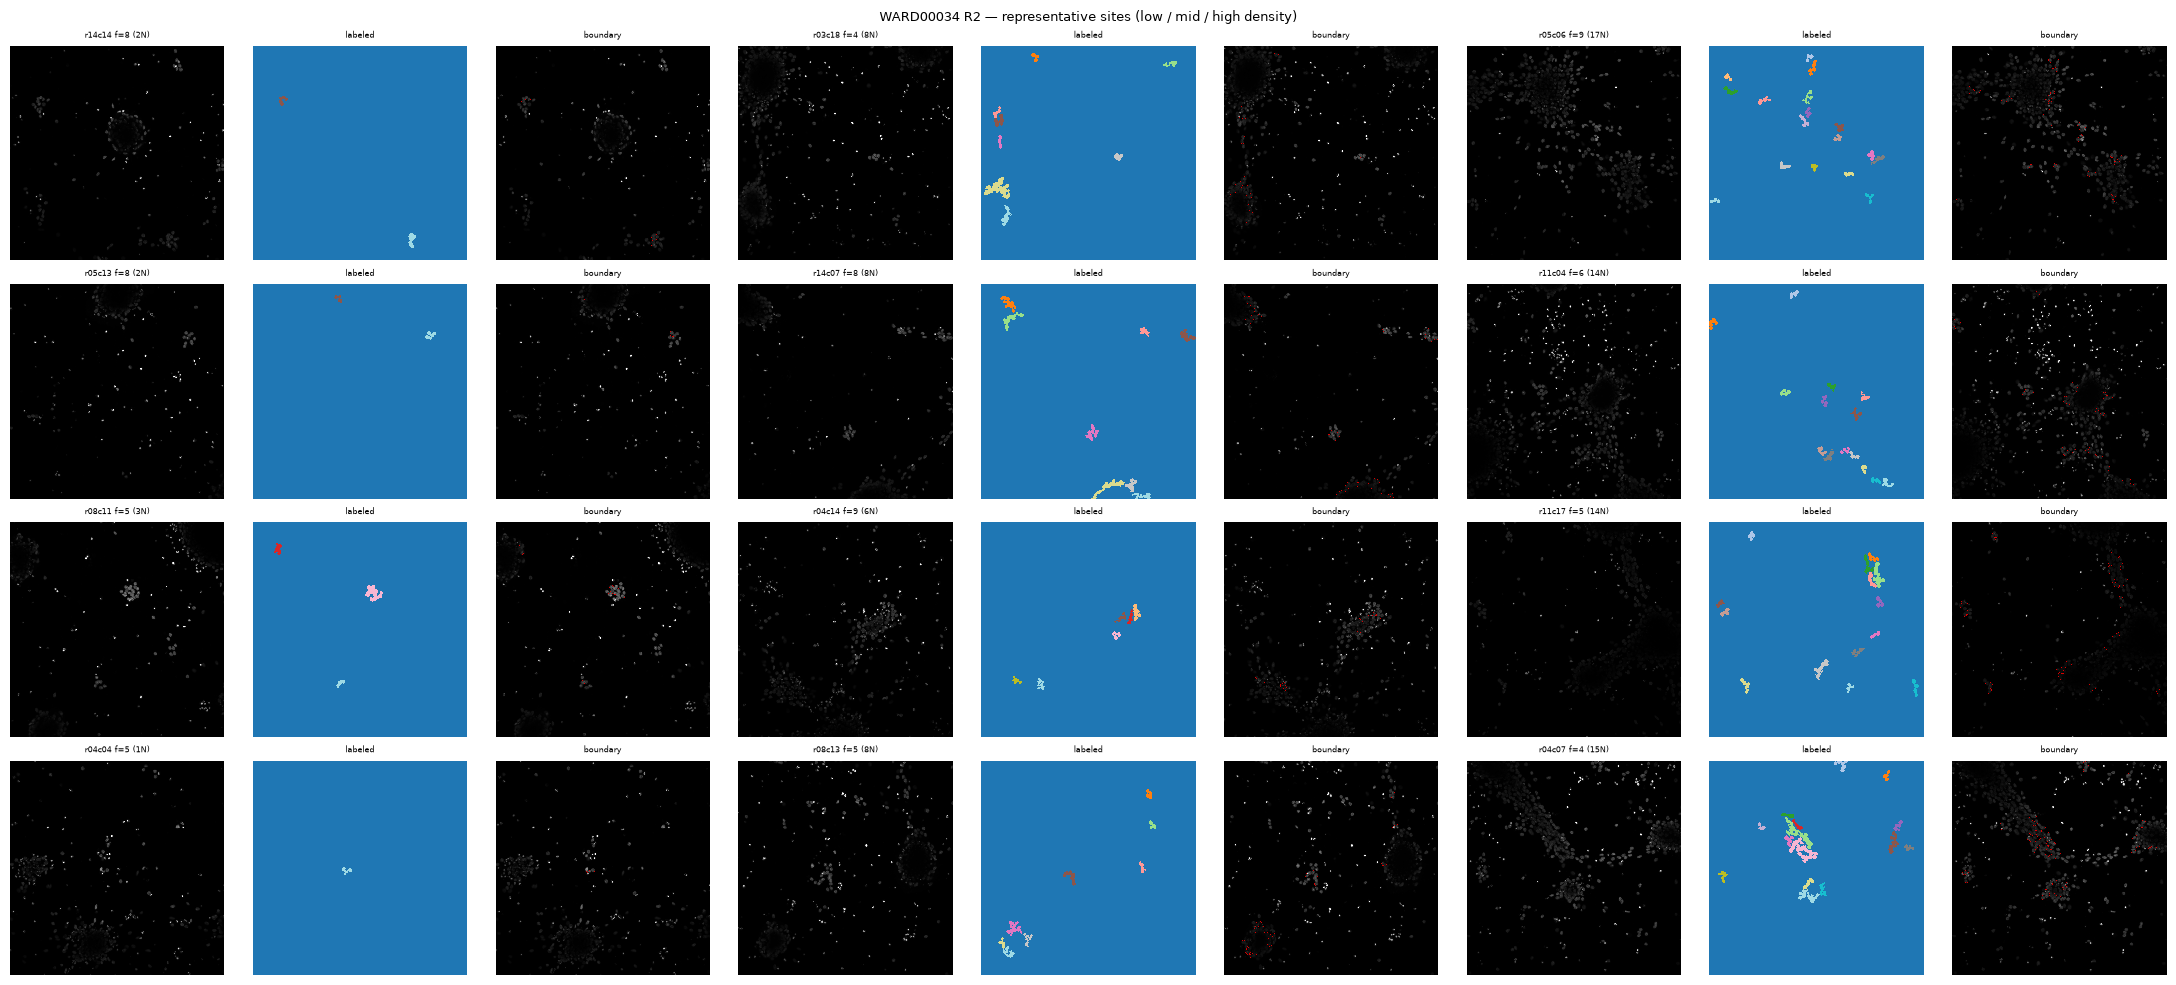

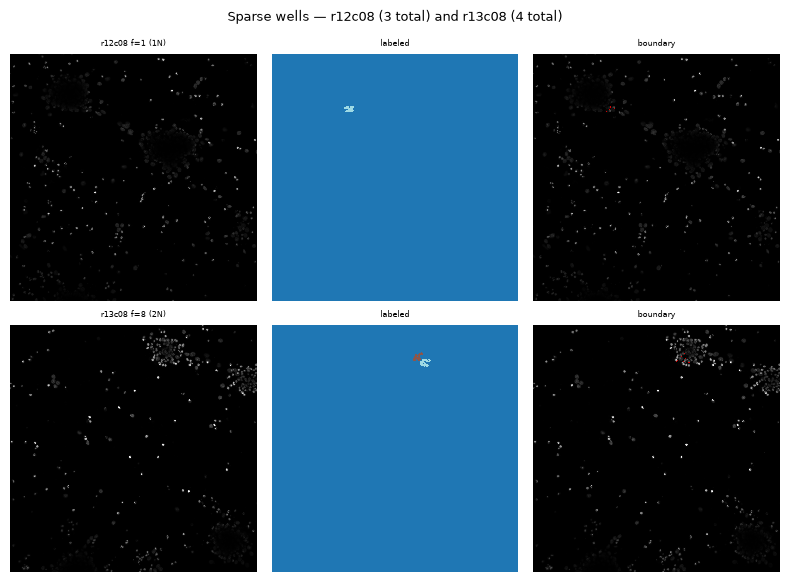

In [4]:
# Pick representative sites across nucleus-count distribution
ps = df.groupby(["Row", "Column", "Frame"]).size().reset_index(name="n")

low_sites  = ps[ps["n"] <= 3].sample(4, random_state=42)[["Row", "Column", "Frame"]].values.tolist()
mid_sites  = ps[(ps["n"] >= 5) & (ps["n"] <= 8)].sample(4, random_state=42)[["Row", "Column", "Frame"]].values.tolist()
high_sites = ps[ps["n"] >= 14].sample(4, random_state=42)[["Row", "Column", "Frame"]].values.tolist()

# Interleave: row i shows low[i], mid[i], high[i] — easy visual density comparison
# Layout: 4 rows × 9 cols (3 sites × 3 panels per row)
fig, axes = plt.subplots(4, 9, figsize=(22, 10))
fig.suptitle("WARD00034 R2 — representative sites (low / mid / high density)", fontsize=9)

group_labels = ["low", "mid", "high"]
for row_i in range(4):
    for col_i, sites in enumerate([low_sites, mid_sites, high_sites]):
        r, c, f = sites[row_i]
        ax0 = axes[row_i, col_i * 3]
        ax1 = axes[row_i, col_i * 3 + 1]
        ax2 = axes[row_i, col_i * 3 + 2]
        if row_i == 0:
            ax0.set_title(f"— {group_labels[col_i]} —", fontsize=8, pad=10)
        show_site(r, c, f, ax0, ax1, ax2)

plt.tight_layout()
fig.savefig(OUT_DIR / "grid_representative_sites.png", dpi=150)
plt.show()

# --- Sparse wells: r12c08 (3 nuclei total) and r13c08 (4 nuclei total) ---
# ponytail: just show one frame per well; both have nuclei in f=1
sparse = [(12, 8, 1), (13, 8, 8)]
fig2, axes2 = plt.subplots(2, 3, figsize=(8, 6))
fig2.suptitle("Sparse wells — r12c08 (3 total) and r13c08 (4 total)", fontsize=9)
for row_i, (r, c, f) in enumerate(sparse):
    show_site(r, c, f, axes2[row_i, 0], axes2[row_i, 1], axes2[row_i, 2])
plt.tight_layout()
fig2.savefig(OUT_DIR / "sparse_wells.png", dpi=150)
plt.show()

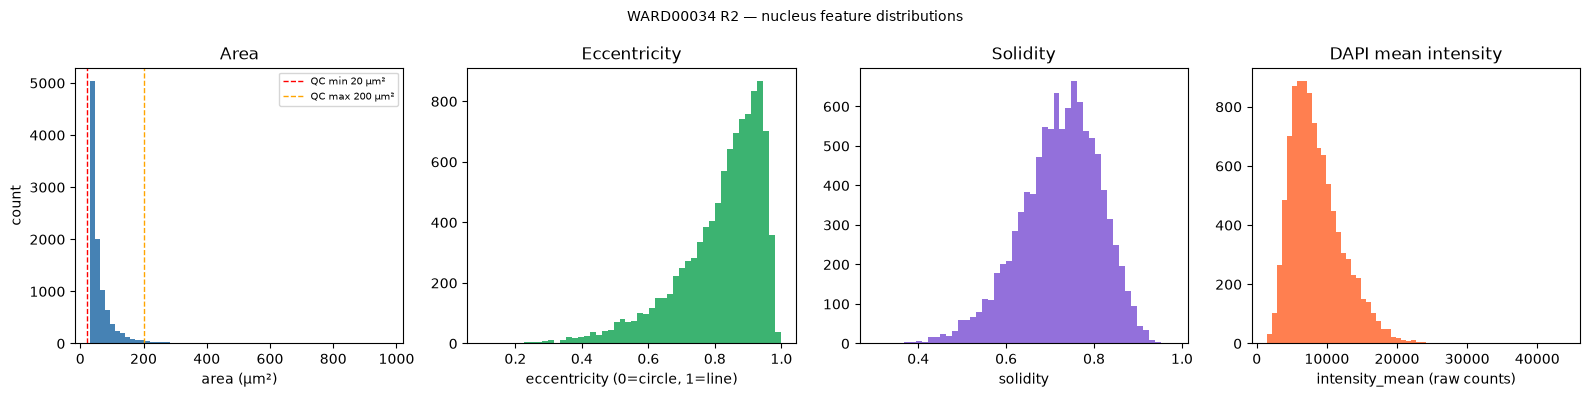

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("WARD00034 R2 — nucleus feature distributions", fontsize=10)

# Area (µm²)
ax = axes[0]
ax.hist(df["area_um2"], bins=60, color="steelblue", edgecolor="none")
ax.axvline(20,  color="red",    linestyle="--", linewidth=1, label="QC min 20 µm²")
ax.axvline(200, color="orange", linestyle="--", linewidth=1, label="QC max 200 µm²")
ax.set_xlabel("area (µm²)");
ax.set_ylabel("count")
ax.set_title("Area")
ax.legend(fontsize=7)

# Eccentricity
ax = axes[1]
ax.hist(df["eccentricity"], bins=50, color="mediumseagreen", edgecolor="none")
ax.set_xlabel("eccentricity (0=circle, 1=line)")
ax.set_title("Eccentricity")

# Solidity
ax = axes[2]
ax.hist(df["solidity"], bins=50, color="mediumpurple", edgecolor="none")
ax.set_xlabel("solidity")
ax.set_title("Solidity")

# Mean intensity (raw MIP counts)
ax = axes[3]
ax.hist(df["intensity_mean"], bins=60, color="coral", edgecolor="none")
ax.set_xlabel("intensity_mean (raw counts)")
ax.set_title("DAPI mean intensity")

plt.tight_layout()
fig.savefig(OUT_DIR / "feature_distributions.png", dpi=150)
plt.show()